In [92]:
import pandas as pd
import numpy as np
import ast
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [93]:
movies = pd.read_csv('data/tmdb_5000_movies.csv')
credits = pd.read_csv('data/tmdb_5000_credits.csv')

print(movies.shape)
print(credits.shape)

movies.head()

(4803, 20)
(4803, 4)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [94]:
movies.info()
credits.info()

<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   str    
 2   homepage              1712 non-null   str    
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   str    
 5   original_language     4803 non-null   str    
 6   original_title        4803 non-null   str    
 7   overview              4800 non-null   str    
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   str    
 10  production_countries  4803 non-null   str    
 11  release_date          4802 non-null   str    
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   str    
 15  status                4803 non-n

In [95]:
movies = movies.merge(credits, on='title')

movies.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,movie_id,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,285,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,206647,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,49026,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,49529,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [96]:
movies.shape

(4809, 23)

In [97]:
desired_cols = [
    'movie_id','title','overview','genres','keywords','cast','crew',
    'release_date','runtime','vote_average','vote_count','popularity','poster_path'
]

available = [c for c in desired_cols if c in movies.columns]
missing = [c for c in desired_cols if c not in movies.columns]
if missing:
    print("Missing columns (will be skipped):", missing)

movies = movies[available]


Missing columns (will be skipped): ['poster_path']


In [98]:
movies.isnull().sum()

movie_id        0
title           0
overview        3
genres          0
keywords        0
cast            0
crew            0
release_date    1
runtime         2
vote_average    0
vote_count      0
popularity      0
dtype: int64

In [99]:
movies.dropna(subset=['overview'], inplace=True)

In [100]:
movies.duplicated().sum()

np.int64(0)

In [101]:
movies.describe()

,movie_id,runtime,vote_average,vote_count,popularity
count,4806.000000,4806.000000,4806.000000,4806.000000,4806.000000
mean,56922.559509,106.887224,6.093258,690.758427,21.504750
std,88309.447559,22.602261,1.190846,1234.454061,31.808977
min,5.000000,0.000000,0.000000,0.000000,0.000000
25%,9009.750000,94.000000,5.600000,54.000000,4.680875
50%,14615.500000,103.500000,6.200000,236.000000,12.928897
75%,58476.750000,118.000000,6.800000,737.750000,28.350828
max,447027.000000,338.000000,10.000000,13752.000000,875.581305


In [102]:
movies[['title', 'vote_average', 'vote_count', 'popularity']].sort_values(
    by='vote_average', ascending=False
).head(10)

,title,vote_average,vote_count,popularity
4050,"Dancer, Texas Pop. 81",10.0,1,0.376662
4252,Me You and Five Bucks,10.0,2,0.094105
3522,Stiff Upper Lips,10.0,1,0.356495
4668,Little Big Top,10.0,1,0.092100
3997,Sardaarji,9.5,2,0.296981
2388,One Man's Hero,9.3,2,0.910529
1883,The Shawshank Redemption,8.5,8205,136.747729
2973,There Goes My Baby,8.5,2,0.037073
2798,The Prisoner of Zenda,8.4,11,4.021389
3340,The Godfather,8.4,5893,143.659698


In [103]:
movies['release_year'] = pd.to_datetime(
    movies['release_date'], errors='coerce'
).dt.year

In [104]:
C = movies['vote_average'].mean()
m = movies['vote_count'].quantile(0.90)

def weighted_rating(row):
    v = row['vote_count']
    R = row['vote_average']
    return (v / (v + m) * R) + (m / (v + m) * C)

movies['weighted_tmdb_rating'] = movies.apply(weighted_rating, axis=1)

In [105]:
def runtime_category(runtime):
    if pd.isna(runtime):
        return 'Unknown'
    elif runtime < 90:
        return 'Short'
    elif runtime <= 150:
        return 'Medium'
    else:
        return 'Long'

movies['runtime_category'] = movies['runtime'].apply(runtime_category)

In [106]:
def rating_category(score):
    if score >= 8:
        return 'Excellent'
    elif score >= 7:
        return 'Good'
    elif score >= 6:
        return 'Average'
    else:
        return 'Low'

movies['rating_category'] = movies['weighted_tmdb_rating'].apply(rating_category)

In [107]:
movies['movie_display'] = (
    movies['title'] + 
    ' (' + movies['release_year'].fillna(0).astype(int).astype(str) + ')'
)

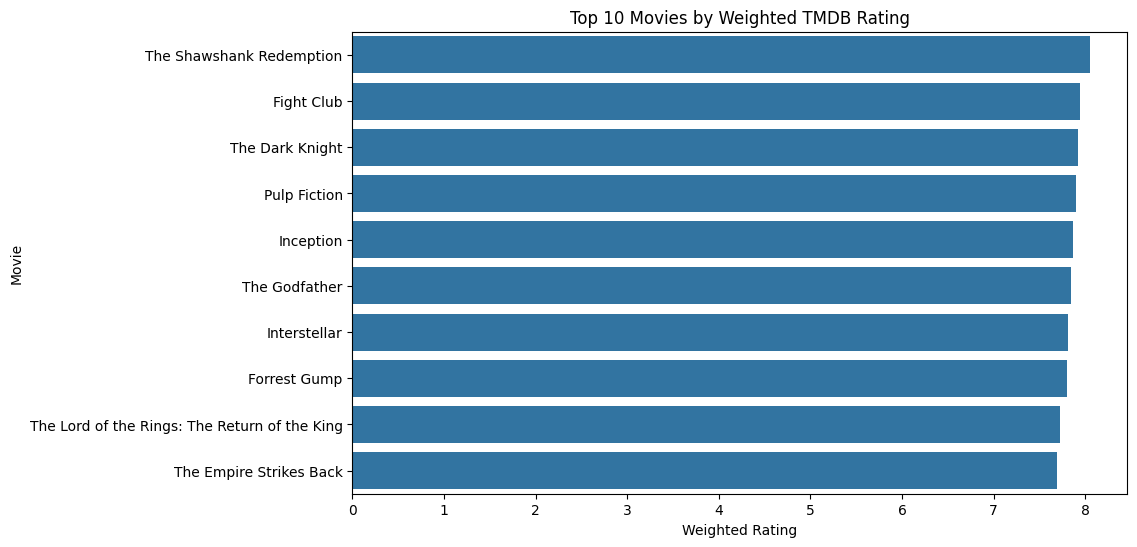

In [108]:
top_rated = movies.sort_values(
    by='weighted_tmdb_rating', ascending=False
).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_rated, x='weighted_tmdb_rating', y='title')
plt.title('Top 10 Movies by Weighted TMDB Rating')
plt.xlabel('Weighted Rating')
plt.ylabel('Movie')
plt.show()

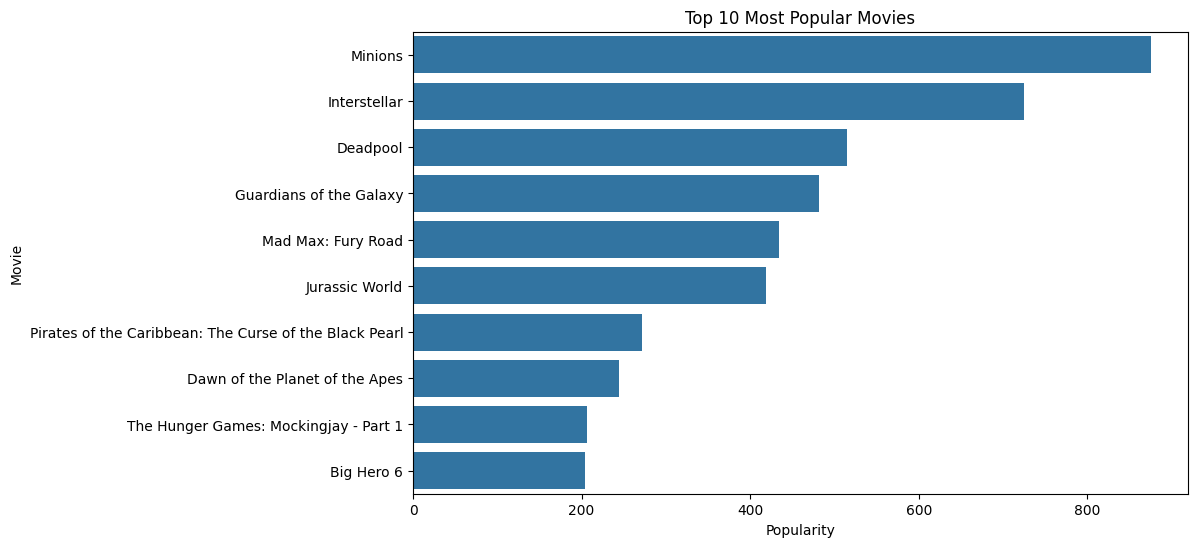

In [109]:
popular_movies = movies.sort_values(
    by='popularity', ascending=False
).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=popular_movies, x='popularity', y='title')
plt.title('Top 10 Most Popular Movies')
plt.xlabel('Popularity')
plt.ylabel('Movie')
plt.show()

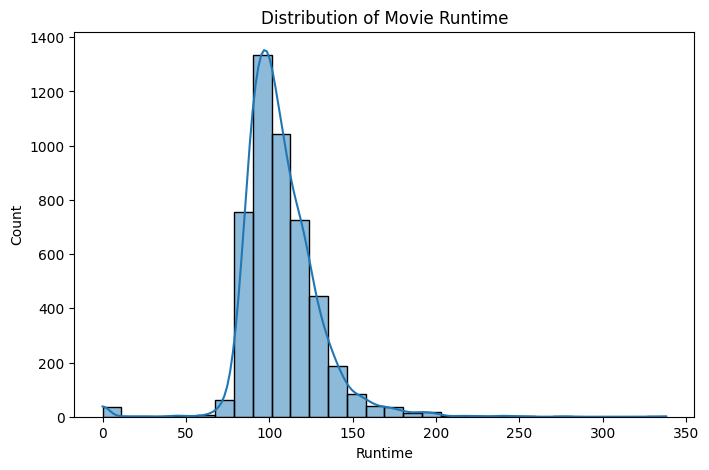

In [110]:
plt.figure(figsize=(8, 5))
sns.histplot(movies['runtime'].dropna(), bins=30, kde=True)
plt.title('Distribution of Movie Runtime')
plt.xlabel('Runtime')
plt.ylabel('Count')
plt.show()

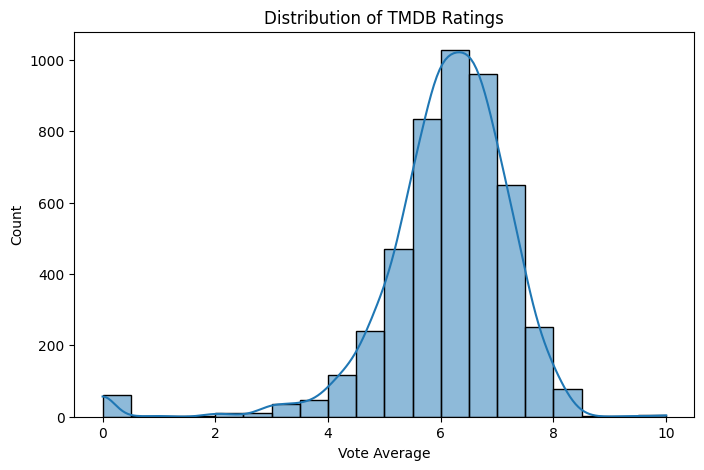

In [111]:
plt.figure(figsize=(8, 5))
sns.histplot(movies['vote_average'], bins=20, kde=True)
plt.title('Distribution of TMDB Ratings')
plt.xlabel('Vote Average')
plt.ylabel('Count')
plt.show()

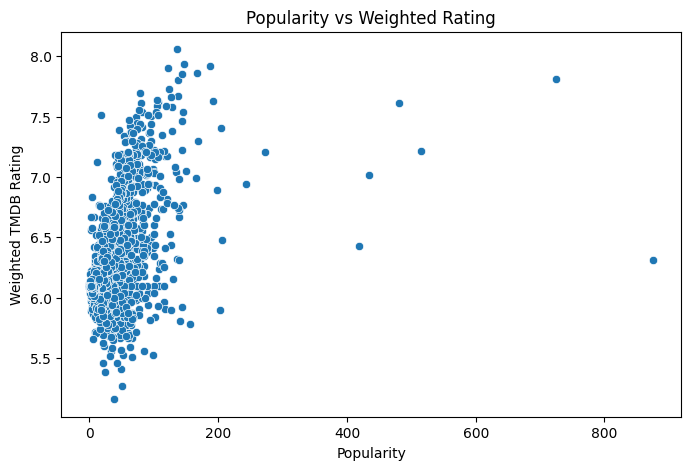

In [112]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=movies,
    x='popularity',
    y='weighted_tmdb_rating'
)
plt.title('Popularity vs Weighted Rating')
plt.xlabel('Popularity')
plt.ylabel('Weighted TMDB Rating')
plt.show()

In [113]:
def convert(obj):
    items = []
    for i in ast.literal_eval(obj):
        items.append(i['name'])
    return items

In [114]:
movies['genres'] = movies['genres'].apply(convert)
movies['keywords'] = movies['keywords'].apply(convert)

In [115]:
def convert_cast(obj):
    items = []
    counter = 0
    
    for i in ast.literal_eval(obj):
        if counter < 3:
            items.append(i['name'])
            counter += 1
        else:
            break
            
    return items

In [116]:
movies['cast'] = movies['cast'].apply(convert_cast)

In [117]:
def fetch_director(obj):
    items = []
    
    for i in ast.literal_eval(obj):
        if i['job'] == 'Director':
            items.append(i['name'])
            break
            
    return items

In [118]:
movies['crew'] = movies['crew'].apply(fetch_director)

In [119]:
movies.rename(columns={'crew': 'director'}, inplace=True)

In [120]:
movies['overview'] = movies['overview'].apply(lambda x: x.split())

In [121]:
def remove_spaces(words):
    return [i.replace(" ", "") for i in words]

In [122]:
movies['genres'] = movies['genres'].apply(remove_spaces)
movies['keywords'] = movies['keywords'].apply(remove_spaces)
movies['cast'] = movies['cast'].apply(remove_spaces)
movies['director'] = movies['director'].apply(remove_spaces)

In [123]:
movies['tags'] = (
    movies['overview'] +
    movies['genres'] +
    movies['keywords'] +
    movies['cast'] +
    movies['director']
)

In [124]:
cols = [
    'movie_id',
    'title',
    'movie_display',
    'tags',
    'release_year',
    'runtime',
    'runtime_category',
    'vote_average',
    'vote_count',
    'weighted_tmdb_rating',
    'rating_category',
    'popularity'
]

if 'poster_path' in movies.columns:
    cols.append('poster_path')

new_movies = movies[cols]

In [136]:
def create_poster_url(poster_path):
    if pd.isna(poster_path):
        return "https://via.placeholder.com/500x750?text=No+Poster"
    return "https://image.tmdb.org/t/p/w500" + poster_path

def create_poster_url(poster_path):
    if pd.isna(poster_path):
        return "https://via.placeholder.com/500x750?text=No+Poster"
    return "https://image.tmdb.org/t/p/w500" + poster_path

if 'poster_path' in new_movies.columns:
    new_movies['poster_url'] = new_movies['poster_path'].apply(create_poster_url)
else:
    new_movies['poster_url'] = "https://via.placeholder.com/500x750?text=No+Poster"

In [141]:
new_movies.head()

,movie_id,title,movie_display,tags,release_year,runtime,runtime_category,vote_average,vote_count,weighted_tmdb_rating,rating_category,popularity,poster_url
0,19995,Avatar,Avatar (2009),"[In, the, 22nd, century,, a, paraplegic, Marin...",2009.0,162.0,Long,7.2,11800,7.050318,Good,150.437577,https://via.placeholder.com/500x750?text=No+Po...
1,285,Pirates of the Caribbean: At World's End,Pirates of the Caribbean: At World's End (2007),"[Captain, Barbossa,, long, believed, to, be, d...",2007.0,169.0,Long,6.9,4500,6.665370,Average,139.082615,https://via.placeholder.com/500x750?text=No+Po...
2,206647,Spectre,Spectre (2015),"[A, cryptic, message, from, Bond’s, past, send...",2015.0,148.0,Medium,6.3,4466,6.239548,Average,107.376788,https://via.placeholder.com/500x750?text=No+Po...
3,49026,The Dark Knight Rises,The Dark Knight Rises (2012),"[Following, the, death, of, District, Attorney...",2012.0,165.0,Long,7.6,9106,7.346090,Good,112.312950,https://via.placeholder.com/500x750?text=No+Po...
4,49529,John Carter,John Carter (2012),"[John, Carter, is, a, war-weary,, former, mili...",2012.0,132.0,Medium,6.1,2124,6.096866,Average,43.926995,https://via.placeholder.com/500x750?text=No+Po...


In [143]:
new_movies[['movie_display', 'poster_url']].head()

,movie_display,poster_url
0,Avatar (2009),https://via.placeholder.com/500x750?text=No+Po...
1,Pirates of the Caribbean: At World's End (2007),https://via.placeholder.com/500x750?text=No+Po...
2,Spectre (2015),https://via.placeholder.com/500x750?text=No+Po...
3,The Dark Knight Rises (2012),https://via.placeholder.com/500x750?text=No+Po...
4,John Carter (2012),https://via.placeholder.com/500x750?text=No+Po...


In [137]:
cv = CountVectorizer(max_features=5000, stop_words='english')
vectors = cv.fit_transform(new_movies['tags'].apply(lambda x: ' '.join(x))).toarray()

In [138]:
vectors.shape

(4806, 5000)

In [139]:
similarity = cosine_similarity(vectors)

similarity.shape

(4806, 4806)

In [128]:
def recommend(movie):
    movie_index = new_movies[new_movies['title'] == movie].index[0]
    distances = similarity[movie_index]
    
    movie_list = sorted(
        list(enumerate(distances)),
        reverse=True,
        key=lambda x: x[1]
    )[1:6]
    
    for i in movie_list:
        print(new_movies.iloc[i[0]].title)

In [129]:
recommend('Avatar')

Titan A.E.
Small Soldiers
Independence Day
Ender's Game
Aliens vs Predator: Requiem


In [130]:
def recommend(movie):
    movie_index = new_movies[new_movies['title'] == movie].index[0]
    distances = similarity[movie_index]
    
    movie_list = sorted(
        list(enumerate(distances)),
        reverse=True,
        key=lambda x: x[1]
    )[1:11]
    
    recommendations = []
    
    for i in movie_list:
        recommendations.append({
            'title': new_movies.iloc[i[0]].title,
            'movie_display': new_movies.iloc[i[0]].movie_display,
            'similarity_score': i[1],
            'weighted_tmdb_rating': new_movies.iloc[i[0]].weighted_tmdb_rating,
            'rating_category': new_movies.iloc[i[0]].rating_category
        })
    
    recommendations_df = pd.DataFrame(recommendations)
    
    recommendations_df = recommendations_df.sort_values(
        by=['similarity_score', 'weighted_tmdb_rating'],
        ascending=False
    )
    
    return recommendations_df.head(5)

In [131]:
new_movies['weighted_tmdb_rating'] = movies['weighted_tmdb_rating'].values
new_movies['rating_category'] = movies['rating_category'].values

recommend('The Dark Knight')

,title,movie_display,similarity_score,weighted_tmdb_rating,rating_category
0,The Dark Knight Rises,The Dark Knight Rises (2012),0.423911,7.346090,Good
1,Batman Begins,Batman Begins (2005),0.398031,7.217949,Good
2,Batman Returns,Batman Returns (1992),0.321588,6.334207,Average
3,Batman Forever,Batman Forever (1995),0.287912,5.693049,Low
4,Batman & Robin,Batman & Robin (1997),0.267946,5.270632,Low


In [132]:
new_movies['weighted_tmdb_rating'] = movies['weighted_tmdb_rating'].values
new_movies['rating_category'] = movies['rating_category'].values

recommend('The Godfather')

,title,movie_display,similarity_score,weighted_tmdb_rating,rating_category
0,Desert Dancer,Desert Dancer (2014),0.510113,6.097187,Average
1,Take the Lead,Take the Lead (2006),0.394665,6.134151,Average
2,Step Up 2: The Streets,Step Up 2: The Streets (2008),0.340777,6.197992,Average
3,Center Stage,Center Stage (2000),0.336596,6.126122,Average
4,Footloose,Footloose (1984),0.329956,6.159161,Average


In [144]:
import pickle

pickle.dump(new_movies, open('model.pkl', 'wb'))
pickle.dump(similarity, open('similarity.pkl', 'wb'))
pickle.dump(similarity, open('similarity.pkl', 'wb'))